# XGBoost

### Import needed libraries

In [95]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb


### Initialize dataframes with aggregate data

In [96]:
phy30sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_30s.csv', encoding="utf-8-sig")
phy16sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_16s.csv', encoding="utf-8-sig")
phy10sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_10s.csv', encoding="utf-8-sig")
scada30sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_30s.csv', encoding="utf-8-sig")
scada16sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_16s.csv', encoding="utf-8-sig")
scada10sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_10s.csv', encoding="utf-8-sig")

comb30sdf = pd.concat([phy30sdf, scada30sdf], ignore_index= True)
comb16sdf = pd.concat([phy16sdf, scada16sdf], ignore_index= True)
comb10sdf = pd.concat([phy10sdf, scada10sdf], ignore_index= True)


## Train a regression model for the 30 second time frame

### Extract feature and target arrays

In [97]:
X, y = comb16sdf.drop('num_attacks', axis=1), comb16sdf[['num_attacks']]

### Convert text features to categories

In [98]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype('category')

### Split the data

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Convert into DMatrix

In [100]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

### Define hyperparameters

In [101]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

### Train the model

In [102]:
n = 1000
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

preds = model.predict(dtest_reg)

### Cross validate

In [103]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=39
)

### Inspect CV results object

In [104]:
print('results columns:', list(results.columns))
print(results.head())

results columns: ['train-rmse-mean', 'train-rmse-std', 'test-rmse-mean', 'test-rmse-std']
   train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
0      2371.257053      200.296490     2116.503833    1247.312515
1      1870.226967      131.436437     1751.123849     984.592441
2      1477.780951       83.327927     1467.813466     780.892905
3      1170.158728       50.537166     1246.629380     631.883287
4       929.372385       29.028479     1074.472356     528.056725


### Find the MSE,  RMSE, R^2

In [105]:
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else np.asarray(y_test).ravel()
mse = mean_squared_error(y_test_arr, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_arr, preds)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}')

MSE: 197115.0469, RMSE: 443.9764, R^2: 0.3735


### predicted vs actual scatter

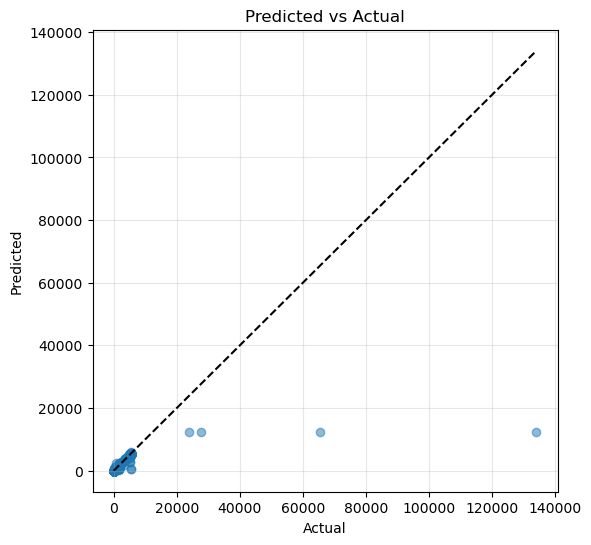

In [106]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_arr, preds, alpha=0.5)
lims = [min(y_test_arr.min(), preds.min()), max(y_test_arr.max(), preds.max())]
plt.plot(lims, lims, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(alpha=0.3)
plt.show()

In [107]:
# Copy generic variables into 16s-specific names to avoid cross-section reuse
# Run this cell after you run the 16s training/predict cells
if 'model' in globals():
    model_16s = model
if 'preds' in globals():
    preds_16s = preds
if 'X_test' in globals():
    X_test_16s = X_test
if 'y_test' in globals():
    y_test_16s = y_test
if 'dtest_reg' in globals():
    dtest_reg_16s = dtest_reg
if 'dtrain_reg' in globals():
    dtrain_reg_16s = dtrain_reg
if 'results' in globals():
    results_16s = results
print('Copied generic variables to *_16s names (if present)')

Copied generic variables to *_16s names (if present)


## Repeat for the 16 second time frame

### Extract feature and target arrays

In [108]:
X, y = comb16sdf.drop('num_attacks', axis=1), comb16sdf[['num_attacks']]

### Convert text features to categories

In [109]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype('category')

### Split the data

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Convert into DMatrix

In [111]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

### Define hyperparameters

In [112]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

### Train the model

In [113]:
n = 1000
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

preds = model.predict(dtest_reg)

### Cross validate

In [114]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=39
)

### Inspect results

In [115]:
print('results columns:', list(results.columns))
print(results.head())

results columns: ['train-rmse-mean', 'train-rmse-std', 'test-rmse-mean', 'test-rmse-std']
   train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
0      2371.257053      200.296490     2116.503833    1247.312515
1      1870.226967      131.436437     1751.123849     984.592441
2      1477.780951       83.327927     1467.813466     780.892905
3      1170.158728       50.537166     1246.629380     631.883287
4       929.372385       29.028479     1074.472356     528.056725


### Find MSE, RMSE, R^2

In [116]:
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else np.asarray(y_test).ravel()
mse = mean_squared_error(y_test_arr, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_arr, preds)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}')

MSE: 197115.0469, RMSE: 443.9764, R^2: 0.3735


### Predicted v. actual scatter

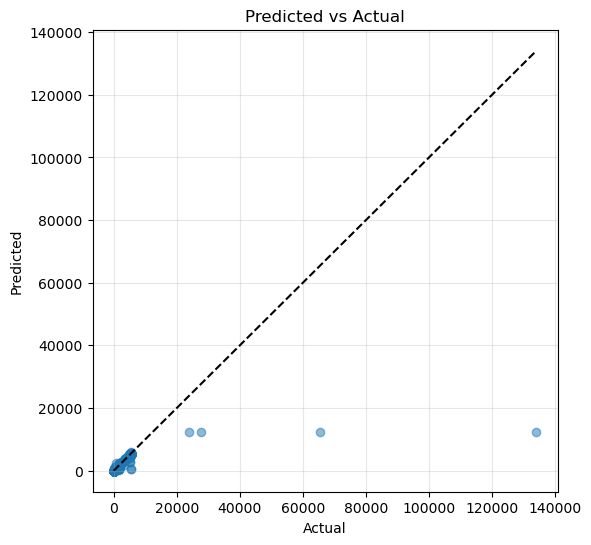

In [117]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_arr, preds, alpha=0.5)
lims = [min(y_test_arr.min(), preds.min()), max(y_test_arr.max(), preds.max())]
plt.plot(lims, lims, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(alpha=0.3)
plt.show()

## Repeat for the 10 second time frame

### Extract feature and target arrays

In [118]:
X, y = comb10sdf.drop('num_attacks', axis=1), comb10sdf[['num_attacks']]

### Convert text features to categories

In [119]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype('category')

### Split the data

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Convert into DMatrix

In [121]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

### Define hyperparameters

In [122]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

### Train the model

In [123]:
n = 1000
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

preds = model.predict(dtest_reg)

### Cross validate

In [124]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=39
)

### Inspect results

In [125]:
print('results columns:', list(results.columns))
print(results.head())

results columns: ['train-rmse-mean', 'train-rmse-std', 'test-rmse-mean', 'test-rmse-std']
   train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
0      1438.419349      500.495146     1306.098326     1479.50789


### Find MSE, RMSE, R^2

In [126]:
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else np.asarray(y_test).ravel()
mse = mean_squared_error(y_test_arr, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_arr, preds)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}')

MSE: 3698294.7500, RMSE: 1923.0951, R^2: 0.0383


### Predicted v actual scatter

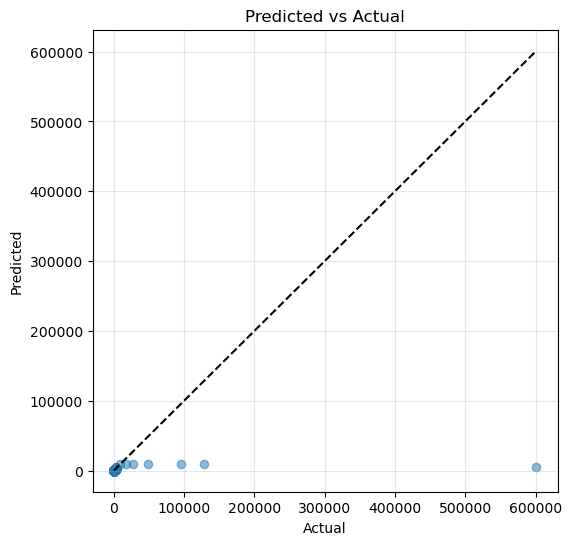

In [127]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_arr, preds, alpha=0.5)
lims = [min(y_test_arr.min(), preds.min()), max(y_test_arr.max(), preds.max())]
plt.plot(lims, lims, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(alpha=0.3)
plt.show()